In [ ]:
# 1. Import required libraries and set up HANA Cloud connection
from hana_ml import dataframe
import pandas as pd
import numpy as np
from hana_ml.dataframe import ConnectionContext
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split

# Connect to SAP HANA Cloud
cc = dataframe.ConnectionContext(
    "6291b51a-ea33-4ade-bb5c-0b8f1a032b9d.hana.demo-hc-3-hna0-hc-dev.dev-aws.hanacloud.ondemand.com",
    user="None",
    password="Abcd1234",
    port=443,
)

In [2]:
# 2. Generate dynamic synthetic data
num_features = 6
num_samples = 100
np.random.seed(42)
df = pd.DataFrame(
    np.random.rand(num_samples, num_features),
    columns=[f"F{i}" for i in range(num_features)]
)
df["TARGET"] = np.random.randint(0, 2, num_samples)
df["INDEX"] = range(num_samples)

print("First rows of generated DataFrame:")
print(df.head())

First rows of generated DataFrame:
         F0        F1        F2        F3        F4        F5  TARGET  INDEX
0  0.374540  0.950714  0.731994  0.598658  0.156019  0.155995       0      0
1  0.058084  0.866176  0.601115  0.708073  0.020584  0.969910       1      1
2  0.832443  0.212339  0.181825  0.183405  0.304242  0.524756       1      2
3  0.431945  0.291229  0.611853  0.139494  0.292145  0.366362       1      3
4  0.456070  0.785176  0.199674  0.514234  0.592415  0.046450       0      4


In [3]:
# 3. Save synthetic data to HANA Cloud
from hana_ml.dataframe import create_dataframe_from_pandas
create_dataframe_from_pandas(
    connection_context=cc,
    pandas_df=df,
    table_name='GENERATED_DT_DATA_TBL',
    force=True
)

100%|██████████| 1/1 [00:00<00:00,  2.91it/s]


In [4]:
# 4. Load data from HANA table and define features/target
hana_table = cc.table('GENERATED_DT_DATA_TBL')
hana_columns = hana_table.columns
target = 'TARGET'
features = [col for col in hana_columns if col not in [target, "INDEX"]]
key = "INDEX"
print("Used features:", features)

X = df[features].values
y = df[target].values

Used features: ['F0', 'F1', 'F2', 'F3', 'F4', 'F5']


In [5]:
# 5. Preprocessing pipeline for numeric features
X_df = df[features].copy()
X_df = X_df.replace({pd.NA: np.nan})

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler()),
    ('variance', VarianceThreshold(threshold=0.01))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features)
    ]
)

X_preprocessed = preprocessor.fit_transform(X_df)

In [6]:
# 6. Show data before and after preprocessing
print("Data before preprocessing:")
print(X[:5])
print("Data after preprocessing:")
print(X_preprocessed[:5])

Data before preprocessing:
[[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452]
 [0.05808361 0.86617615 0.60111501 0.70807258 0.02058449 0.96990985]
 [0.83244264 0.21233911 0.18182497 0.18340451 0.30424224 0.52475643]
 [0.43194502 0.29122914 0.61185289 0.13949386 0.29214465 0.36636184]
 [0.45606998 0.78517596 0.19967378 0.51423444 0.59241457 0.04645041]]
Data after preprocessing:
[[0.37464402 0.95705237 0.73959407 0.59205878 0.15223964 0.14977056]
 [0.05336284 0.87111933 0.60608827 0.70335038 0.0156548  0.98955553]
 [0.83952769 0.20649392 0.17838269 0.1696792  0.3017226  0.53025327]
 [0.43292411 0.28668564 0.61704168 0.12501506 0.28952222 0.36682424]
 [0.45741689 0.78878263 0.19658975 0.50618605 0.59234333 0.03674468]]


In [7]:
# 7. Train-test split
X_train_preprocessed, X_test_preprocessed, y_train, y_test = train_test_split(
    X_preprocessed, y, test_size=0.2, random_state=42
)

In [8]:
# 8. Import and initialize DecisionTree tool
from hana_ai.tools.hana_ml_tools.decisiontree_tools import DecisionTreeFitAndSave
dt_tool = DecisionTreeFitAndSave(cc)

In [9]:
# 9. Train the Decision Tree model
dt_tool.run(tool_input={
    "name": "my_decisiontree_model",
    "version": 1,
    "fit_table": "GENERATED_DT_DATA_TBL",
    "target": target,
    "features": features,
    "max_depth": 6,
    "min_records_of_leaf": 2,
    "thread_ratio": 0.5,
    "key": key
})

'{"status": "success", "model_name": "my_decisiontree_model", "model_version": 1, "trained_table": "GENERATED_DT_DATA_TBL"}'

In [10]:

# 10. Import and initialize prediction tool
from hana_ai.tools.hana_ml_tools.decisiontree_tools import DecisionTreeLoadModelAndPredict
dt_predict_tool = DecisionTreeLoadModelAndPredict(cc)

In [12]:
# 11. Run prediction tool
predictions = dt_predict_tool.run(tool_input={
    "name": "my_decisiontree_model",
    "version": 1,
    "predict_table": "GENERATED_DT_DATA_TBL",
    "features": features,
    "key": key
})

import json
if isinstance(predictions, str):
    predictions_dict = json.loads(predictions)
else:
    predictions_dict = predictions

pred_df = pd.DataFrame(predictions_dict["predictions"])
print(pred_df.head())

   INDEX SCORE  CONFIDENCE
0      0     0    1.000000
1      1     0    0.814815
2      2     1    0.818182
3      3     1    0.818182
4      4     0    0.764706


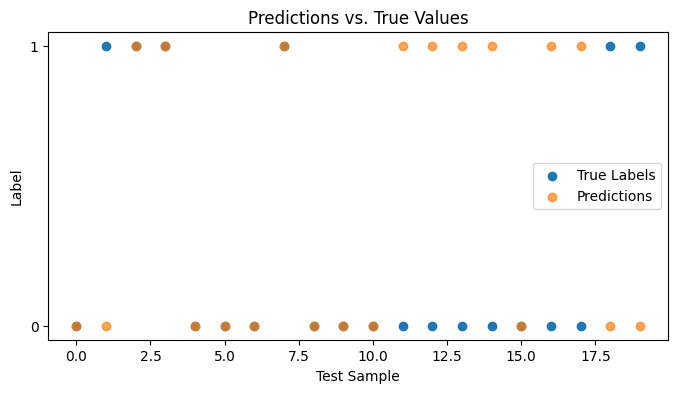

In [13]:
# 12. Postprocessing after prediction (Analysis & Visualization)
import matplotlib.pyplot as plt

if 'PREDICTION' in pred_df.columns:
    y_pred = pred_df['PREDICTION'].values
elif 'SCORE' in pred_df.columns:
    y_pred = pred_df['SCORE'].values
else:
    print("Available columns:", pred_df.columns)
    raise ValueError("Prediction column not found!")

min_len = min(len(y_test), len(y_pred))
plt.figure(figsize=(8,4))
plt.scatter(range(min_len), y_test[:min_len], label='True Labels')
plt.scatter(range(min_len), y_pred[:min_len], label='Predictions', alpha=0.7)
plt.legend()
plt.title('Predictions vs. True Values')
plt.xlabel('Test Sample')
plt.ylabel('Label')
plt.show()


In [14]:
# 13. Set up LangChain integration for LLM-based agent
from langchain.agents import initialize_agent, AgentType
from gen_ai_hub.proxy.langchain import init_llm

llm = init_llm('gpt-4o', temperature=0.0, max_tokens=1800)
tools = [dt_tool, dt_predict_tool]
agent_chain = initialize_agent(
    tools,
    llm,
    agent=AgentType.STRUCTURED_CHAT_ZERO_SHOT_REACT_DESCRIPTION,
)


/var/folders/s0/lpt_8gsd7mld2dfq18l7ryfm0000gn/T/ipykernel_23020/1959539612.py:7: LangChainDeprecationWarning: LangChain agents will continue to be supported, but it is recommended for new use cases to be built with LangGraph. LangGraph offers a more flexible and full-featured framework for building agents, including support for tool-calling, persistence of state, and human-in-the-loop workflows. For details, refer to the `LangGraph documentation <https://langchain-ai.github.io/langgraph/>`_ as well as guides for `Migrating from AgentExecutor <https://python.langchain.com/docs/how_to/migrate_agent/>`_ and LangGraph's `Pre-built ReAct agent <https://langchain-ai.github.io/langgraph/how-tos/create-react-agent/>`_.
  agent_chain = initialize_agent(


In [15]:
# 14. Use agent for modeling task
agent_chain.invoke(f"""
    Train a Decision Tree model for synthetic binary classification.

    Data:
    - Table: GENERATED_DT_DATA_TBL
    - Target variable: {target}
    - Features: {', '.join(features)}
    - Key: {key}

    Model Configuration:
    - Model name: my_decisiontree_model
    - Version: 1
    - Maximum depth: 6
    - Minimum records per leaf: 2
    - Thread ratio: 0.5

    Note: Features are numeric and data is normalized where appropriate.
""")

{'input': '\n    Train a Decision Tree model for synthetic binary classification.\n\n    Data:\n    - Table: GENERATED_DT_DATA_TBL\n    - Target variable: TARGET\n    - Features: F0, F1, F2, F3, F4, F5\n    - Key: INDEX\n\n    Model Configuration:\n    - Model name: my_decisiontree_model\n    - Version: 1\n    - Maximum depth: 6\n    - Minimum records per leaf: 2\n    - Thread ratio: 0.5\n\n    Note: Features are numeric and data is normalized where appropriate.\n',
 'output': "The Decision Tree model 'my_decisiontree_model' has been successfully trained and saved with version 1 using the table 'GENERATED_DT_DATA_TBL'."}

In [16]:
# --- LangChain Agent Natural Language Test Cases ---

instruction = "Please provide all JSON outputs strictly without comments. Always specify the 'features' parameter as a non-empty list of column names. Always specify the 'key' parameter as the name of the index column (usually 'INDEX'). Always specify the correct target column name (usually 'TARGET')."

print("Test: Train a Decision Tree that ignores features with less than 5% variance.")
agent_chain.invoke(f"""
    {instruction}
    Train a Decision Tree model for binary classification.
    Ignore features with less than 5% variance.
    Use max_depth=6 and min_records_of_leaf=2.
    Table: GENERATED_DT_DATA_TBL
    Target: TARGET
    Features: {features}
    Key: INDEX
""")

print("Test: Predict only for rows where F1 > 0.8.")
agent_chain.invoke(f"""
    {instruction}
    Predict only for rows in GENERATED_DT_DATA_TBL where F1 > 0.8.
    Use model my_decisiontree_model version 1.
    Features: {features}
    Key: INDEX
""")

print("Test: Score the model and explain accuracy in one sentence.")
agent_chain.invoke(f"""
    {instruction}
    Score the model accuracy on the test set.
    Explain in one sentence what the accuracy means.
    Use model my_decisiontree_model version 1.
    Table: GENERATED_DT_DATA_TBL
    Target: TARGET
    Features: {features}
    Key: INDEX
""")

Test: Train a Decision Tree that ignores features with less than 5% variance.
Test: Predict only for rows where F1 > 0.8.
Test: Score the model and explain accuracy in one sentence.


{'input': "\n    Please provide all JSON outputs strictly without comments. Always specify the 'features' parameter as a non-empty list of column names. Always specify the 'key' parameter as the name of the index column (usually 'INDEX'). Always specify the correct target column name (usually 'TARGET').\n    Score the model accuracy on the test set.\n    Explain in one sentence what the accuracy means.\n    Use model my_decisiontree_model version 1.\n    Table: GENERATED_DT_DATA_TBL\n    Target: TARGET\n    Features: ['F0', 'F1', 'F2', 'F3', 'F4', 'F5']\n    Key: INDEX\n",
 'output': "The accuracy of the model is calculated by comparing the predicted 'SCORE' values with the actual 'TARGET' values in the test set. The accuracy represents the proportion of correct predictions made by the model out of all predictions."}